In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [5]:
df = pd.read_csv('data.csv')
df.head()

,Weight,Height
0,45,120
1,50,130
2,20,60
3,35,135
4,70,150


In [6]:
df.shape

(22, 2)

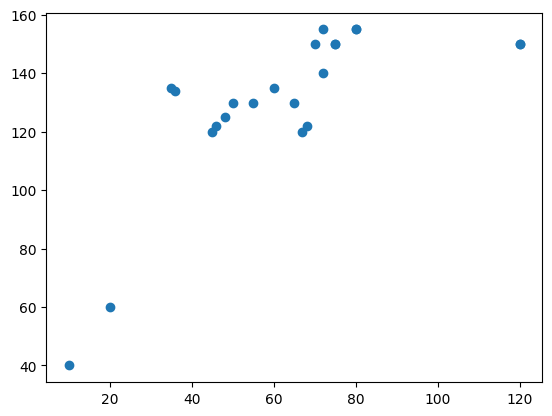

In [7]:
plt.scatter(df['Weight'] , df['Height'])

In [8]:
# df_clean = df[(df['Weight'] > 30) & (df['Height'] > 100)]

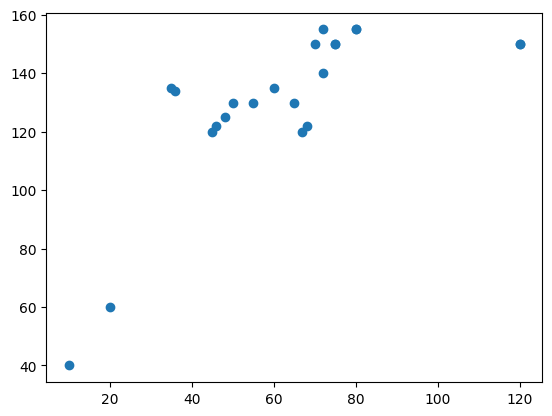

In [9]:
plt.scatter(df['Weight'] , df['Height'])

## Divide the dataset into dependent feature and independent features

In [10]:
# dependent Feature
x = df[['Weight']]
# Independent features
y = df['Height']

In [11]:
y.head()

0    120
1    130
2     60
3    135
4    150
Name: Height, dtype: int64

In [12]:
x.head()

,Weight
0,45
1,50
2,20
3,35
4,70


### Train Test Split of the dataset

In [13]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=41)

In [14]:
x_train.shape , y_train.shape , x_test.shape , y_test.shape

((15, 1), (15,), (7, 1), (7,))

## Feature Scaling or Standardization of DataSet

In [15]:
s = x_train.loc[18]-x_train.mean()
z_score = s/x_train.std()
z_score

Weight    2.094435
dtype: float64

In [16]:
s = x_test - x_test.mean()
s/x_test.std()

,Weight
19,0.705227
11,0.521026
17,0.521026
13,0.705227
4,0.336825
21,-0.915743
6,-1.873589


In [17]:
# ## Feature Scaling or Standardization of DataSet for Train Independent Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_test_scaled

array([[ 0.650131  ],
       [ 0.46040406],
       [ 0.46040406],
       [ 0.650131  ],
       [ 0.27067711],
       [-1.01946612],
       [-2.00604624]])

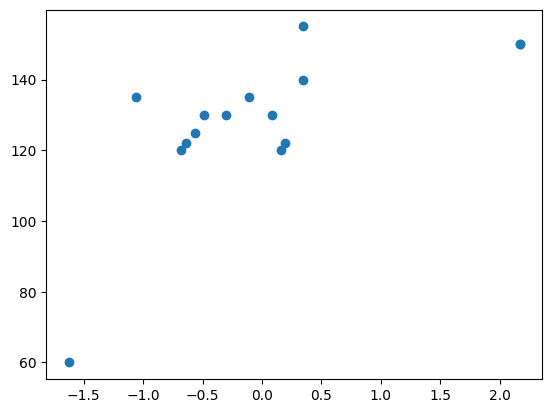

In [18]:
plt.scatter(x_train_scaled , y_train)

## Model Training Using Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lr = LinearRegression()

Mean Absolute Error :  23.14365157579292
R2 Score :  0.49686882267150334


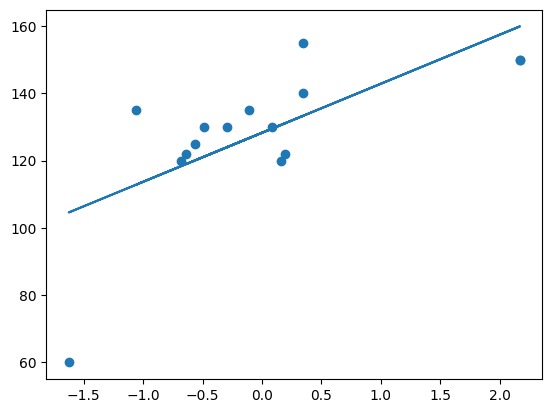

In [20]:
lr.fit(x_train_scaled , y_train)
y_pred = lr.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("Mean Absolute Error : " , mae)
print("R2 Score : " , score)
plt.scatter(x_train_scaled , y_train)
plt.plot(x_train_scaled , lr.predict(x_train_scaled))

In [21]:
lr.coef_

array([14.56478953])

In [22]:
lr.intercept_

np.float64(128.26666666666668)

In [23]:
x_test_scaled * lr.coef_ + lr.intercept_

array([[137.73568787],
       [134.97235483],
       [134.97235483],
       [137.73568787],
       [132.2090218 ],
       [113.41835716],
       [ 99.04902538]])

In [24]:
df.corr()

,Weight,Height
Weight,1.000000,0.739706
Height,0.739706,1.000000


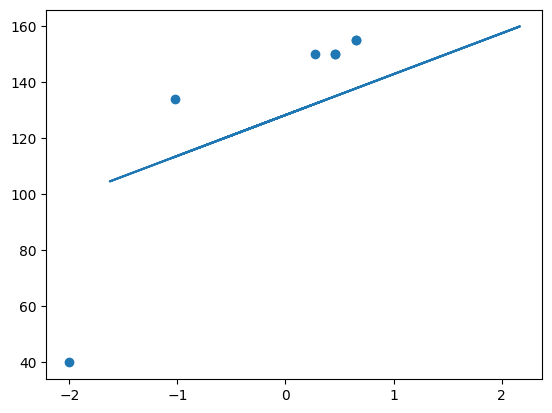

In [25]:
plt.scatter(x_test_scaled , y_test)
plt.plot(x_train_scaled , lr.predict(x_train_scaled))

In [26]:
df[['Weight','Height']].corr()

,Weight,Height
Weight,1.000000,0.739706
Height,0.739706,1.000000


<!-- Performence Metric
MSE , MAE , RMSE
R Square and Adjusted R Square -->

## Performence Metrics
## MAE , MSE , RMSE
## R Square and Adjuste R Square

In [27]:
from sklearn.metrics import mean_squared_error , mean_absolute_error

In [34]:
mse = mean_squared_error(x_test_scaled , y_pred)

In [35]:
mse

16355.385614453236